# Benchmarking different solvers for Traveling Salesman Problem (TSP) QUBO Instances

**Notebook prepared by: Sabah Ud Din Ahmad**

In this notebook, I solve a standard Traveling Salesman Problem (TSP) QUBO with classical and quantum methods, then compare solution quality and runtime.

### Execution Backends

**1. Quantum: Qiskit simulator using `StatevectorSampler`**

`StatevectorSampler` is Qiskit's local reference simulator. It runs on local computer and simulates an ideal quantum state. It has no hardware noise, no queue time, and no device connectivity constraints. In this notebook, I use it to test standard QAOA and warm-start QAOA in an ideal local setting.

**2. Quantum: Qiskit simulator using Aer `SamplerV2`**

Aer `SamplerV2` is also local simulation, but it behaves more like a shot-based backend. It returns sampled bitstrings from a finite number of shots and can be extended later with noise models. In this notebook, I use it as a hardware-like local simulator for standard QAOA and warm-start QAOA.

**3. Quantum: IBM hardware**

This is running the code on a real IBM quantum processor accessed through `qiskit_ibm_runtime`. The hardware examples optimize QAOA parameters locally first, then send the fixed optimized circuit to IBM hardware for sampling. This avoids running the full classical optimizer loop on hardware, which would require many submitted jobs.

So the hardware workflow is:

```text
QUBO -> local QAOA optimization -> optimized circuit -> IBM hardware sampling -> measured bitstrings
```

The IBM hardware result is therefore not produced by the simulator, but it does depend on the locally optimized circuit parameters.

### Notebook Structure

1. Shared imports, QUBO utilities, TSP utilities, and benchmark helpers
2. Example `n_cities = 3` test problem
3. Standard QAOA examples: Statevector, Aer, IBM hardware
4. Warm-start QAOA examples: Statevector, Aer, IBM hardware
5. Classical Gurobi example
6. Configurable benchmarking section with solver flags and plot flags

### Local Environment

The intended local Python environment is:

```text
../Warm-Start-QAOA-IEEE/IBM/.venv/bin/python
```


In [1]:
# Import Python's system module to report the active interpreter version.
import sys

# Print the Python version used by the current Jupyter kernel.
print("Python version:", sys.version.split()[0])

Python version: 3.13.0


In [2]:
# List packages used by the notebook for optimization, simulation, plotting, and IBM Runtime.
packages = [
    "numpy",
    "matplotlib",
    "jupyterlab",
    "ipykernel",
    "qiskit",
    "qiskit-aer",
    "qiskit-ibm-runtime",
    "qiskit-optimization",
    "qiskit-algorithms",
    "pylatexenc",
    "gurobipy"
]

# Import package metadata so installed versions can be checked without importing every package.
import importlib.metadata as metadata

# Print each package version, or show that the package is missing.
for pkg in packages:
    try:
        print(f"{pkg:25} {metadata.version(pkg)}")
    except metadata.PackageNotFoundError:
        print(f"{pkg:25} NOT INSTALLED")

numpy                     2.4.6
matplotlib                3.10.9
jupyterlab                4.5.7
ipykernel                 7.2.0
qiskit                    2.4.1
qiskit-aer                0.17.2
qiskit-ibm-runtime        0.47.0
qiskit-optimization       0.7.0
qiskit-algorithms         0.4.0
pylatexenc                2.10
gurobipy                  13.0.2


In [3]:
# Required packages
# Run this once if your environment does not already have these packages.
# This line is intentionally commented out so the notebook does not install packages automatically.
# %pip install -U qiskit qiskit-aer qiskit-algorithms qiskit-optimization qiskit-ibm-runtime gurobipy

### Shared Imports


In [4]:
# Import NumPy for matrices, vectors, random generation, and QUBO energy calculations.
import numpy as np
# Import Matplotlib for plotting TSP routes and benchmark charts.
import matplotlib.pyplot as plt
# Import warnings so noisy package warnings can be hidden in tutorial-style output.
import warnings
# Import a high-resolution monotonic timer for runtime benchmarking.
from time import perf_counter

# QuadraticProgram stores binary quadratic optimization problems in Qiskit's optimization module.
from qiskit_optimization import QuadraticProgram
# MinimumEigenOptimizer wraps QAOA as a solver for QuadraticProgram objects.
from qiskit_optimization.algorithms import MinimumEigenOptimizer
# WarmStartQAOAOptimizer builds warm-start QAOA from a continuous relaxation of the binary problem.
from qiskit_optimization.algorithms import WarmStartQAOAOptimizer
# CobylaOptimizer solves the continuous relaxation used by warm-start QAOA.
from qiskit_optimization.algorithms import CobylaOptimizer

# QAOA is the variational quantum algorithm used to search for low-energy QUBO bitstrings.
from qiskit_algorithms import QAOA
# COBYLA tunes the QAOA angles during the variational optimization loop.
from qiskit_algorithms.optimizers import COBYLA
# algorithm_globals provides a central random seed for qiskit-algorithms.
from qiskit_algorithms.utils import algorithm_globals

# StatevectorSampler is the local ideal reference sampler.
from qiskit.primitives import StatevectorSampler
# generate_preset_pass_manager creates transpilation pipelines for simulators and hardware.
from qiskit.transpiler import generate_preset_pass_manager

# Suppress warnings so notebook output focuses on solver behavior and benchmark results.
warnings.filterwarnings("ignore")

# Confirm that the Qiskit imports completed successfully.
print("IBM Qiskit imports successful.")

IBM Qiskit imports successful.


### Shared QUBO Utilities


In [5]:
def validate_qubo_matrix(Q):
    """
    Validate a QUBO matrix.

    Args:
        Q: Candidate QUBO coefficient matrix.

    Returns:
        A finite square NumPy array with dtype float.

    Raises:
        ValueError: If Q is not two-dimensional, square, or finite.
    """
    # Convert the input to a floating-point NumPy array for predictable matrix operations.
    Q = np.asarray(Q, dtype=float)

    # Ensure the matrix has row and column dimensions.
    if Q.ndim != 2:
        raise ValueError("Q must be a two-dimensional matrix.")

    # Ensure x^T Q x is well-defined with the same number of rows and columns.
    if Q.shape[0] != Q.shape[1]:
        raise ValueError("Q must be square.")

    # Ensure all coefficients are real finite values.
    if not np.all(np.isfinite(Q)):
        raise ValueError("Q must contain only finite real numbers.")

    # Return the normalized matrix for downstream use.
    return Q

def qubo_matrix_to_quadratic_program(Q, name="qubo_problem"):
    """
    Convert a QUBO matrix into a Qiskit QuadraticProgram.

    Args:
        Q: Square QUBO matrix defining x^T Q x.
        name: Name assigned to the Qiskit optimization model.

    Returns:
        A QuadraticProgram with binary variables and a minimization objective.
    """
    # Validate the QUBO matrix and normalize it to a float ndarray.
    Q = validate_qubo_matrix(Q)
    # Number of binary variables equals the QUBO matrix dimension.
    n = Q.shape[0]
    # Create the Qiskit optimization model.
    qp = QuadraticProgram(name)

    # Add one binary variable for each QUBO bit.
    for i in range(n):
        qp.binary_var(name=f"x_{i}")

    # Store diagonal QUBO terms as linear terms because x_i^2 = x_i for binary variables.
    linear = {}
    # Store off-diagonal QUBO terms as quadratic terms.
    quadratic = {}

    # Copy nonzero diagonal coefficients into the linear objective dictionary.
    for i in range(n):
        if abs(Q[i, i]) > 1e-12:
            linear[f"x_{i}"] = Q[i, i]

    # Combine Q[i,j] and Q[j,i] into one quadratic coefficient for each pair.
    for i in range(n):
        for j in range(i + 1, n):
            coeff = Q[i, j] + Q[j, i]
            if abs(coeff) > 1e-12:
                quadratic[(f"x_{i}", f"x_{j}")] = coeff

    # Register the objective as a minimization problem.
    qp.minimize(linear=linear, quadratic=quadratic)
    # Return the populated Qiskit model.
    return qp

def qubo_energy(Q, x):
    """
    Evaluate the QUBO objective x^T Q x for a binary vector.

    Args:
        Q: Square QUBO matrix.
        x: Binary candidate vector.

    Returns:
        Floating-point QUBO energy.

    Raises:
        ValueError: If x does not match the QUBO dimension.
    """
    # Validate Q before computing the quadratic form.
    Q = validate_qubo_matrix(Q)
    # Convert the candidate assignment to an integer vector.
    x = np.asarray(x, dtype=int)

    # Ensure the candidate bitstring has the same length as the QUBO dimension.
    if x.shape != (Q.shape[0],):
        raise ValueError(f"x must have shape ({Q.shape[0]},).")

    # Return the scalar QUBO energy for this assignment.
    return float(x @ Q @ x)

### Shared QAOA Utilities


In [6]:
def solve_qubo_with_qaoa(
    Q,
    sampler=None,
    reps=1,
    maxiter=200,
    seed=123,
    optimizer=None,
    callback=None,
    transpiler=None,
    transpiler_options=None,
):
    """
    Solve a QUBO with standard QAOA.

    Args:
        Q: Square QUBO matrix.
        sampler: Qiskit sampler backend, such as StatevectorSampler or Aer SamplerV2.
        reps: QAOA depth parameter p.
        maxiter: Maximum number of classical optimizer iterations.
        seed: Random seed for reproducibility.
        optimizer: Optional qiskit-algorithms optimizer for QAOA angles.
        callback: Optional QAOA callback.
        transpiler: Optional transpiler/pass manager.
        transpiler_options: Optional transpiler keyword arguments.

    Returns:
        Dictionary containing solution bits, QUBO energy, Qiskit result objects, and model data.
    """
    # Validate Q before constructing Qiskit optimization objects.
    Q = validate_qubo_matrix(Q)
    # Convert the raw QUBO matrix to Qiskit's QuadraticProgram format.
    qp = qubo_matrix_to_quadratic_program(Q)
    # Convert the QuadraticProgram to an Ising operator plus constant offset for inspection.
    ising_operator, offset = qp.to_ising()

    # Set Qiskit's algorithm seed for reproducibility when a seed is provided.
    algorithm_globals.random_seed = seed

    # Default to the local reference sampler if no sampler is supplied.
    if sampler is None:
        sampler = StatevectorSampler(seed=seed)

    # Default to COBYLA for classical optimization of QAOA angles.
    if optimizer is None:
        optimizer = COBYLA(maxiter=maxiter)

    # Build the QAOA solver with the requested sampler, optimizer, depth, and optional transpiler.
    qaoa = QAOA(
        sampler=sampler,
        optimizer=optimizer,
        reps=reps,
        callback=callback,
        transpiler=transpiler,
        transpiler_options=transpiler_options,
    )

    # Wrap QAOA so it can solve the QuadraticProgram directly.
    qaoa_optimizer = MinimumEigenOptimizer(qaoa)
    # Run the hybrid quantum-classical optimization loop.
    result = qaoa_optimizer.solve(qp)

    # Convert the returned solution vector to integer bits.
    x_qaoa = np.array(result.x, dtype=int)
    # Evaluate the original QUBO energy for the selected bitstring.
    e_qaoa = qubo_energy(Q, x_qaoa)

    # Return a compact result dictionary plus raw Qiskit objects for later inspection or hardware execution.
    return {
        "solver": "Standard QAOA",
        "solution": x_qaoa,
        "qubo_energy": e_qaoa,
        "qiskit_objective": float(result.fval),
        "ising_operator": ising_operator,
        "offset": offset,
        "quadratic_program": qp,
        "raw_result": result,
    }

def solve_qubo_with_warm_start_qaoa(
    Q,
    sampler=None,
    reps=1,
    maxiter=200,
    seed=123,
    optimizer=None,
    pre_solver=None,
    epsilon=0.25,
    callback=None,
    transpiler=None,
    transpiler_options=None,
):
    """
    Solve a QUBO with Qiskit's WarmStartQAOAOptimizer.

    Args:
        Q: Square QUBO matrix.
        sampler: Qiskit sampler backend, such as StatevectorSampler or Aer SamplerV2.
        reps: QAOA depth parameter p.
        maxiter: Maximum number of QAOA optimizer iterations.
        seed: Random seed for reproducibility.
        optimizer: Optional qiskit-algorithms optimizer for QAOA angles.
        pre_solver: Optional qiskit-optimization optimizer for the continuous relaxation.
        epsilon: Warm-start clipping parameter used by Qiskit's warm-start construction.
        callback: Optional QAOA callback.
        transpiler: Optional transpiler/pass manager.
        transpiler_options: Optional transpiler keyword arguments.

    Returns:
        Dictionary containing solution bits, QUBO energy, Qiskit result objects, and model data.
    """
    # Validate Q before building the Qiskit optimization model.
    Q = validate_qubo_matrix(Q)
    # Convert the raw QUBO matrix into a QuadraticProgram.
    qp = qubo_matrix_to_quadratic_program(Q)
    # Keep the Ising operator and offset for consistency with standard QAOA results.
    ising_operator, offset = qp.to_ising()

    # Set Qiskit's algorithm seed for reproducibility when a seed is provided.
    algorithm_globals.random_seed = seed

    # Default to the local reference sampler if no sampler is supplied.
    if sampler is None:
        sampler = StatevectorSampler(seed=seed)

    # Default to COBYLA for QAOA parameter optimization.
    if optimizer is None:
        optimizer = COBYLA(maxiter=maxiter)

    # Default to CobylaOptimizer for the relaxed continuous pre-solve.
    if pre_solver is None:
        pre_solver = CobylaOptimizer()

    # Build the underlying QAOA eigensolver used by the warm-start optimizer.
    qaoa = QAOA(
        sampler=sampler,
        optimizer=optimizer,
        reps=reps,
        callback=callback,
        transpiler=transpiler,
        transpiler_options=transpiler_options,
    )

    # Build the warm-start optimizer around the relaxation pre-solver and QAOA eigensolver.
    warm_optimizer = WarmStartQAOAOptimizer(
        pre_solver=pre_solver,
        relax_for_pre_solver=True,
        qaoa=qaoa,
        epsilon=epsilon,
    )

    # Solve the original binary problem using the warm-started QAOA workflow.
    result = warm_optimizer.solve(qp)

    # Convert the returned solution vector to integer bits.
    x_warm = np.array(result.x, dtype=int)
    # Evaluate the original QUBO energy for the returned bitstring.
    e_warm = qubo_energy(Q, x_warm)

    # Return the same core fields as standard QAOA so benchmark code can treat both uniformly.
    return {
        "solver": "Warm-start QAOA",
        "solution": x_warm,
        "qubo_energy": e_warm,
        "qiskit_objective": float(result.fval),
        "ising_operator": ising_operator,
        "offset": offset,
        "quadratic_program": qp,
        "raw_result": result,
        "warm_start_optimizer": warm_optimizer,
    }

def make_aer_sampler(shots=4096, seed=123):
    """
    Create a local Aer SamplerV2.

    Args:
        shots: Number of measurement shots.
        seed: Random seed for simulator sampling.

    Returns:
        qiskit_aer.primitives.SamplerV2 instance.
    """
    # Import Aer lazily so Qiskit-only cells can run without qiskit-aer until this function is used.
    from qiskit_aer.primitives import SamplerV2 as AerSampler

    # Return a shot-based local sampler with a reproducible seed.
    return AerSampler(
        default_shots=shots,
        seed=seed,
    )

def make_aer_transpiler(seed=123, optimization_level=1):
    """
    Create an Aer-compatible pass manager.

    Args:
        seed: Simulator seed.
        optimization_level: Qiskit preset pass-manager optimization level.

    Returns:
        Pass manager targeted at AerSimulator.
    """
    # Import AerSimulator only when the Aer execution path is used.
    from qiskit_aer import AerSimulator

    # Create an Aer backend object that describes simulator-supported gates.
    aer_backend = AerSimulator(seed_simulator=seed)

    # Build a transpilation pipeline targeted at Aer.
    pass_manager = generate_preset_pass_manager(
        backend=aer_backend,
        optimization_level=optimization_level,
    )

    # Return the pass manager so QAOA can transpile circuits before sampling.
    return pass_manager

def _find_min_eigen_result(obj, max_depth=4):
    """
    Locate a nested QAOA minimum-eigensolver result inside a Qiskit optimization result.

    Args:
        obj: Object to inspect.
        max_depth: Maximum recursive search depth.

    Returns:
        Object exposing optimal_circuit and optimal_parameters.

    Raises:
        RuntimeError: If no compatible nested result is found.
    """
    # Stop recursion when the depth limit is reached or the object is missing.
    if obj is None or max_depth < 0:
        raise RuntimeError("Could not locate a QAOA minimum-eigensolver result.")

    # Return immediately when this object has the fields needed for circuit extraction.
    if hasattr(obj, "optimal_circuit") and hasattr(obj, "optimal_parameters"):
        return obj

    # Check common Qiskit result attribute names that wrap a minimum-eigensolver result.
    for attr in ("min_eigen_solver_result", "minimum_eigen_solver_result", "raw_result"):
        if hasattr(obj, attr):
            try:
                return _find_min_eigen_result(getattr(obj, attr), max_depth=max_depth - 1)
            except RuntimeError:
                pass

    # Search object attributes as a fallback for Qiskit version differences.
    if hasattr(obj, "__dict__"):
        for value in vars(obj).values():
            try:
                return _find_min_eigen_result(value, max_depth=max_depth - 1)
            except RuntimeError:
                pass

    # Raise a clear error if no compatible nested result was found.
    raise RuntimeError("Could not locate a QAOA minimum-eigensolver result.")

def extract_optimized_qaoa_circuit(solve_result):
    """
    Extract an optimized QAOA circuit from a standard or warm-start QAOA result.

    Args:
        solve_result: Result dictionary returned by solve_qubo_with_qaoa or solve_qubo_with_warm_start_qaoa.

    Returns:
        Measured QuantumCircuit with optimized parameters assigned.

    Raises:
        RuntimeError: If this Qiskit version does not expose the optimized circuit in the result object.
    """
    # Read the raw Qiskit optimization result stored in the solver dictionary.
    raw_result = solve_result["raw_result"]
    # Locate the nested minimum-eigensolver result across possible Qiskit result layouts.
    min_eigen_result = _find_min_eigen_result(raw_result)

    # Bind optimized QAOA parameters into the optimal circuit.
    circuit = min_eigen_result.optimal_circuit.assign_parameters(
        min_eigen_result.optimal_parameters
    )

    # Copy the circuit before adding measurement operations.
    measured = circuit.copy()
    # Measure every qubit so a sampler or hardware backend can return classical bitstrings.
    measured.measure_all()

    # Return the measured optimized circuit.
    return measured

### Shared TSP Utilities


In [7]:
def generate_random_distance_matrix(n, min_dist=10, max_dist=100, seed=None):
    """
    Generate a random symmetric TSP distance matrix and 2D city coordinates.

    Args:
        n: Number of cities.
        min_dist: Minimum clipped city distance.
        max_dist: Maximum clipped city distance.
        seed: Optional random seed.

    Returns:
        Tuple `(distance_matrix, coordinates)`.
    """
    # Create a random generator; using a fixed seed makes the TSP instance reproducible.
    rng = np.random.default_rng(seed)
    # Generate random 2D coordinates in a 100 by 100 square.
    coordinates = rng.uniform(0, 100, size=(n, 2))

    # Allocate a square distance matrix with zeros on the diagonal.
    distance_matrix = np.zeros((n, n), dtype=float)
    # Fill the upper triangle and mirror it to create a symmetric TSP instance.
    for i in range(n):
        for j in range(i + 1, n):
            # Compute Euclidean distance between cities i and j.
            dist = np.linalg.norm(coordinates[i] - coordinates[j])
            # Clamp the distance into the requested range and convert it to an integer.
            dist = int(np.clip(dist, min_dist, max_dist))
            # Store distance i -> j.
            distance_matrix[i, j] = dist
            # Store matching distance j -> i.
            distance_matrix[j, i] = dist

    # Return optimization data and plotting coordinates.
    return distance_matrix, coordinates

def tsp_to_qubo(distance_matrix, penalty=None):
    """
    Convert a TSP distance matrix into a QUBO matrix.

    Args:
        distance_matrix: Symmetric n-by-n matrix of city distances.
        penalty: Optional constraint penalty. If None, a scale-based default is used.

    Returns:
        Tuple `(Q, n)` where Q has shape `(n*n, n*n)`.
    """
    # Normalize the distance matrix to floating point coefficients.
    distance_matrix = np.asarray(distance_matrix, dtype=float)
    # Number of cities.
    n = len(distance_matrix)
    # Number of QUBO variables: one variable for every city/time pair.
    N = n * n

    # Choose a penalty large enough to discourage constraint violations.
    if penalty is None:
        penalty = 10 * n * distance_matrix.max()

    # Initialize the full QUBO matrix.
    Q = np.zeros((N, N), dtype=float)

    # Constraint 1: each city is visited exactly once.
    for i in range(n):
        # Iterate over time slots for city i.
        for t1 in range(n):
            # Flatten x[i, t1] into a single QUBO index.
            u = i * n + t1
            # Add the linear part of the exactly-one penalty.
            Q[u, u] -= penalty
            # Penalize selecting city i in two different time slots.
            for t2 in range(t1 + 1, n):
                # Flatten x[i, t2] into a single QUBO index.
                v = i * n + t2
                # Add the quadratic penalty for choosing both time slots.
                Q[u, v] += 2 * penalty

    # Constraint 2: each time step contains exactly one city.
    for t in range(n):
        # Iterate over cities assigned to time slot t.
        for i1 in range(n):
            # Flatten x[i1, t] into a single QUBO index.
            u = i1 * n + t
            # Add the linear part of the exactly-one penalty.
            Q[u, u] -= penalty
            # Penalize selecting two cities at the same time slot.
            for i2 in range(i1 + 1, n):
                # Flatten x[i2, t] into a single QUBO index.
                v = i2 * n + t
                # Add the quadratic penalty for choosing both cities at time t.
                Q[u, v] += 2 * penalty

    # Objective: total route distance.
    for i in range(n):
        # Iterate over departure cities.
        for j in range(n):
            # Skip self-loops.
            if i == j:
                continue
            # Iterate over departure time steps.
            for t in range(n):
                # Variable for city i at time t.
                u = i * n + t
                # Variable for city j at the next time step, wrapping around to close the tour.
                v = j * n + ((t + 1) % n)
                # Add travel distance to the QUBO objective.
                Q[u, v] += distance_matrix[i, j]

    # Return the QUBO matrix and city count.
    return Q, n

def decode_tsp_solution(bits, distance_matrix, verbose=True):
    """
    Decode a flattened TSP QUBO bitstring into a route.

    Args:
        bits: Binary vector with length n*n.
        distance_matrix: TSP distance matrix.
        verbose: Whether to print validation and route details.

    Returns:
        `(route, total_distance)` if valid, otherwise None.
    """
    # Convert the solver output to integer bits.
    bits = np.asarray(bits, dtype=int)
    # Convert distance data to a NumPy array for route indexing.
    distance_matrix = np.asarray(distance_matrix, dtype=float)
    # Number of cities implied by the distance matrix.
    n = len(distance_matrix)

    # The flattened encoding must have one bit for every city/time pair.
    if bits.size != n * n:
        raise ValueError(f"Expected {n*n} bits, got {bits.size}.")

    # Reshape the bitstring into x[city, time].
    x = bits.reshape((n, n))
    # Track whether all TSP constraints are satisfied.
    valid = True

    # Print a decoder header when requested.
    if verbose:
        print("=" * 40)
        print("      TSP QUBO Solution Decoder")
        print("=" * 40)

    # Check that every city appears exactly once.
    for i in range(n):
        count = int(x[i, :].sum())
        if count != 1:
            valid = False
            if verbose:
                print(f"  x City {i} appears {count} times; expected 1.")

    # Check that every time step contains exactly one city.
    for t in range(n):
        count = int(x[:, t].sum())
        if count != 1:
            valid = False
            if verbose:
                print(f"  x Time step {t} has {count} cities; expected 1.")

    # Stop if the bitstring violates the one-city/one-time constraints.
    if not valid:
        if verbose:
            print("\nInvalid solution; constraints are violated.")
            print("\nRaw bit assignment, city x time:")
            print(x)
        return None

    # Extract the selected city at each time step.
    route = [int(np.argmax(x[:, t])) for t in range(n)]
    # Close the route by returning to the starting city.
    route_closed = route + [route[0]]

    # Sum the actual TSP distance along the closed route.
    total_distance = sum(
        distance_matrix[route_closed[k], route_closed[k + 1]]
        for k in range(n)
    )

    # Print the decoded route and distance when requested.
    if verbose:
        print("\nValid solution found.\n")
        for k in range(n):
            frm = route_closed[k]
            to = route_closed[k + 1]
            d = distance_matrix[frm, to]
            print(f"    City {frm} -> City {to}    distance: {d:.0f}")
        print(f"\n  Full route: {' -> '.join(str(c) for c in route_closed)}")
        print(f"  Total distance: {total_distance:.0f}")
        print("=" * 40)

    # Return the route without the repeated final city plus its distance.
    return route, float(total_distance)

def plot_tsp_route(coordinates, route=None, title="TSP"):
    """
    Plot city coordinates and optionally draw a decoded route.

    Args:
        coordinates: Array of 2D city coordinates.
        route: Optional ordered list of city indices.
        title: Plot title.

    Returns:
        None. Displays a Matplotlib figure.
    """
    # Convert coordinates to a floating-point array for plotting.
    coordinates = np.asarray(coordinates, dtype=float)

    # Create a square figure for city locations.
    fig, ax = plt.subplots(figsize=(7, 7))
    # Draw each city as a point.
    ax.scatter(coordinates[:, 0], coordinates[:, 1], s=180, zorder=5)

    # Label every city by index.
    for i, (x_coord, y_coord) in enumerate(coordinates):
        ax.annotate(f" City {i}", (x_coord, y_coord), fontsize=11, zorder=6)

    # Draw route arrows only when a valid decoded route is provided.
    if route is not None:
        route_closed = route + [route[0]]
        for k in range(len(route_closed) - 1):
            frm = route_closed[k]
            to = route_closed[k + 1]
            ax.annotate(
                "",
                xy=coordinates[to],
                xytext=coordinates[frm],
                arrowprops=dict(arrowstyle="->", lw=2),
            )

    # Add plot title and axis labels.
    ax.set_title(title)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    # Add a light grid for readability.
    ax.grid(True, linestyle="--", alpha=0.4)
    # Keep labels inside the plot area.
    plt.tight_layout()
    # Show the figure in the notebook.
    plt.show()

### Shared IBM Hardware Utilities


In [8]:
def _extract_counts_from_sampler_pub_result(pub_result):
    """
    Extract measurement counts from a Qiskit Runtime or Aer SamplerV2 PubResult.

    Args:
        pub_result: One PubResult object returned by SamplerV2.

    Returns:
        Counts dictionary mapping bitstrings to shot counts.

    Raises:
        RuntimeError: If no measurement register with counts is found.
    """
    # Access the structured data payload returned by SamplerV2.
    data = pub_result.data

    # Most circuits created by measure_all() use a classical register called "meas".
    if hasattr(data, "meas"):
        return data.meas.get_counts()

    # Fallback for nonstandard classical register names.
    for attr in dir(data):
        # Skip private/internal attributes.
        if attr.startswith("_"):
            continue
        # Inspect public attributes for a measurement register with get_counts().
        obj = getattr(data, attr)
        if hasattr(obj, "get_counts"):
            return obj.get_counts()

    # Raise a clear error if no measurement counts are available.
    raise RuntimeError("Could not find a measurement register with get_counts().")

def best_bitstring_from_counts(counts, Q):
    """
    Select the lowest-energy measured bitstring from sampler counts.

    Args:
        counts: Dictionary mapping measured classical bitstrings to counts.
        Q: Square QUBO matrix used to score each measured bitstring.

    Returns:
        Tuple `(best_bits, best_energy, best_count)`.
    """
    # Validate Q before evaluating measured assignments.
    Q = validate_qubo_matrix(Q)

    # Store the best measured assignment found so far.
    best_bits = None
    # Initialize the best energy so any valid measured bitstring improves it.
    best_energy = np.inf
    # Track measurement frequency for tie-breaking.
    best_count = 0

    # Evaluate every measured classical bitstring.
    for bitstring, count in counts.items():
        # Remove spaces Qiskit may insert between classical registers.
        clean = bitstring.replace(" ", "")
        # Reverse bit order so array index 0 corresponds to qubit/variable 0.
        bits = np.array([int(bit) for bit in clean[::-1]], dtype=int)

        # Ignore measurements whose length does not match this QUBO.
        if bits.size != Q.shape[0]:
            continue

        # Compute the original QUBO energy for this measured bitstring.
        energy = qubo_energy(Q, bits)

        # Prefer lower energy; if energies tie, prefer the more frequently measured bitstring.
        if (energy < best_energy) or (energy == best_energy and count > best_count):
            best_bits = bits
            best_energy = energy
            best_count = count

    # Fail clearly if no measurement had the expected bit length.
    if best_bits is None:
        raise RuntimeError("No measured bitstring matched the QUBO dimension.")

    # Return the selected assignment, its energy, and its measurement count.
    return best_bits, best_energy, best_count

def run_measured_circuit_on_ibm_hardware(
    measured_circuit,
    Q,
    backend_name=None,
    shots=4096,
    optimization_level=3,
):
    """
    Run a measured circuit on IBM hardware and select the lowest-energy measured bitstring.

    Args:
        measured_circuit: QuantumCircuit with measurements already attached.
        Q: Square QUBO matrix used to score measured bitstrings.
        backend_name: Optional IBM backend name. If None, least-busy eligible backend is selected.
        shots: Number of hardware shots.
        optimization_level: Qiskit preset transpiler optimization level.

    Returns:
        Dictionary containing backend, job, counts, best bitstring, energy, count, and transpiled circuit.
    """
    # Import hardware-specific tools only when this function is called.
    from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as RuntimeSampler

    # Load the saved IBM Quantum account and Runtime configuration.
    service = QiskitRuntimeService()

    # Automatically choose the least-busy real backend with enough qubits if no backend is specified.
    if backend_name is None:
        backend = service.least_busy(
            operational=True,
            simulator=False,
            min_num_qubits=measured_circuit.num_qubits,
        )
    else:
        # Otherwise use the explicitly named backend.
        backend = service.backend(backend_name)

    # Create a backend-aware transpiler.
    pass_manager = generate_preset_pass_manager(
        backend=backend,
        optimization_level=optimization_level,
    )
    # Transpile the measured circuit into the backend's native instruction set.
    isa_circuit = pass_manager.run(measured_circuit)

    # Create a Runtime SamplerV2 bound to the selected backend.
    sampler = RuntimeSampler(mode=backend)

    # Submit the job, supporting both current and older Runtime shot-setting APIs.
    try:
        sampler.options.default_shots = shots
        job = sampler.run([isa_circuit])
    except Exception:
        job = sampler.run([isa_circuit], shots=shots)

    # Wait for the job result.
    result = job.result()

    # Extract measured bitstring counts from the sampler result.
    counts = _extract_counts_from_sampler_pub_result(result[0])
    # Select the lowest-energy measured bitstring according to the original QUBO.
    best_bits, best_energy, best_count = best_bitstring_from_counts(counts, Q)

    # Return hardware metadata, raw counts, selected solution, and transpiled circuit.
    return {
        "backend": backend,
        "job": job,
        "counts": counts,
        "best_bits": best_bits,
        "best_energy": best_energy,
        "best_count": best_count,
        "transpiled_circuit": isa_circuit,
    }

def run_optimized_qaoa_result_on_ibm_hardware(
    solve_result,
    Q,
    backend_name=None,
    shots=4096,
    optimization_level=3,
):
    """
    Sample a locally optimized QAOA result on IBM hardware.

    Args:
        solve_result: Result dictionary from standard or warm-start QAOA.
        Q: Square QUBO matrix used to score measured bitstrings.
        backend_name: Optional IBM backend name.
        shots: Number of hardware shots.
        optimization_level: Qiskit preset transpiler optimization level.

    Returns:
        Dictionary containing IBM sampling results and selected best bitstring.
    """
    # Extract the optimized local QAOA circuit and add measurements.
    measured_circuit = extract_optimized_qaoa_circuit(solve_result)
    # Run that fixed measured circuit on IBM hardware.
    return run_measured_circuit_on_ibm_hardware(
        measured_circuit,
        Q,
        backend_name=backend_name,
        shots=shots,
        optimization_level=optimization_level,
    )

### Shared Benchmark Utilities


In [9]:
def timed_solver_run(label, solve_fn, *args, **kwargs):
    """
    Run a solver function once and attach wall-clock runtime.

    Args:
        label: Human-readable solver label.
        solve_fn: Callable that returns a solver result dictionary.
        *args: Positional arguments passed to solve_fn.
        **kwargs: Keyword arguments passed to solve_fn.

    Returns:
        Solver result dictionary with `solver` and `runtime_seconds` fields added.
    """
    # Record the start time immediately before calling the solver.
    start = perf_counter()
    # Execute the supplied solver function with all provided arguments.
    result = solve_fn(*args, **kwargs)
    # Measure elapsed wall-clock time when the solver returns.
    elapsed = perf_counter() - start
    # Store the label so benchmark tables have a human-readable solver name.
    result["solver"] = label
    # Store the measured runtime in seconds.
    result["runtime_seconds"] = elapsed
    # Return the original result enriched with timing metadata.
    return result

def format_route(route):
    """
    Format a decoded TSP route for tables.

    Args:
        route: List of city indices, or None for an invalid assignment.

    Returns:
        Human-readable closed route string, or `invalid` when no valid route exists.
    """
    # Return an explicit marker when no valid route was decoded.
    if route is None:
        return "invalid"
    # Close the route by returning to the starting city before formatting.
    route_closed = route + [route[0]]
    # Join city indices into a compact route string.
    return " -> ".join(str(city) for city in route_closed)

def summarize_solver_result(label, result, Q, distance_matrix, baseline_distance=None):
    """
    Create one benchmark row from a solver result.

    Args:
        label: Human-readable solver label.
        result: Solver result dictionary or bitstring array.
        Q: Square QUBO matrix.
        distance_matrix: TSP distance matrix.
        baseline_distance: Optional best/reference route distance for relative error.

    Returns:
        Dictionary with validity, route, route distance, energy, runtime, relative error, and bitstring.
    """
    # Extract the binary solution from a result dictionary or use the supplied array directly.
    bits = np.asarray(result["solution"] if isinstance(result, dict) else result, dtype=int)
    # Compute the original QUBO energy for this bitstring.
    energy = qubo_energy(Q, bits)
    # Decode the bitstring without printing so the benchmark table stays compact.
    decoded = decode_tsp_solution(bits, distance_matrix, verbose=False)
    # A decoded route exists only if all TSP constraints are satisfied.
    is_valid = decoded is not None
    # Store route and distance only for valid TSP assignments.
    route = decoded[0] if is_valid else None
    route_distance = decoded[1] if is_valid else np.nan
    # Read runtime from the result dictionary when available.
    runtime_seconds = result.get("runtime_seconds", np.nan) if isinstance(result, dict) else np.nan

    # Compute relative error only when both current and baseline distances are usable.
    if baseline_distance is not None and is_valid and baseline_distance > 0:
        relative_error = (route_distance - baseline_distance) / baseline_distance
    else:
        relative_error = np.nan

    # Return a flat dictionary suitable for printing and plotting.
    return {
        "solver": label,
        "valid": is_valid,
        "route": route,
        "route_text": format_route(route),
        "route_distance": route_distance,
        "qubo_energy": energy,
        "runtime_seconds": runtime_seconds,
        "relative_error": relative_error,
        "bitstring": bits,
    }

def print_benchmark_table(rows):
    """
    Print a compact text table for benchmark rows.

    Args:
        rows: List of benchmark row dictionaries.

    Returns:
        None. Prints a formatted table.
    """
    # Print the table header with an explicit route column.
    print(
        f"{'Solver':32} {'Valid':>7} {'Optimal/Decoded Route':>24} "
        f"{'Distance':>12} {'Rel. err.':>10} {'QUBO energy':>14} {'Runtime (s)':>12}"
    )
    print("-" * 120)
    # Print one aligned row per solver result.
    for row in rows:
        distance = row["route_distance"]
        distance_text = "nan" if np.isnan(distance) else f"{distance:.3f}"
        rel_error = row["relative_error"]
        rel_error_text = "nan" if np.isnan(rel_error) else f"{rel_error:.3%}"
        runtime = row["runtime_seconds"]
        runtime_text = "nan" if runtime is None or np.isnan(runtime) else f"{runtime:.4f}"
        route_text = row.get("route_text", format_route(row.get("route")))
        print(
            f"{row['solver']:32} {str(row['valid']):>7} {route_text:>24} "
            f"{distance_text:>12} {rel_error_text:>10} {row['qubo_energy']:>14.3f} {runtime_text:>12}"
        )

def plot_selected_benchmark_metrics(
    rows,
    n_cities,
    plot_route_distance=True,
    plot_qubo_energy=True,
    plot_runtime=True,
    plot_validity=True,
    plot_relative_error=True,
):
    """
    Plot selected benchmark metrics with TSP-specific titles.

    Args:
        rows: List of benchmark row dictionaries.
        n_cities: Number of cities used in this benchmark run.
        plot_route_distance: Whether to plot decoded route distance.
        plot_qubo_energy: Whether to plot raw QUBO energy.
        plot_runtime: Whether to plot wall-clock runtime.
        plot_validity: Whether to plot valid-solution indicators.
        plot_relative_error: Whether to plot relative error versus baseline.

    Returns:
        None. Displays one or more Matplotlib figures.
    """
    # Build a list of metric plotting requests controlled by flags.
    metric_specs = []
    # Add route-distance plot when enabled.
    if plot_route_distance:
        metric_specs.append((f"TSP Total Distance for {n_cities} Cities", "Total route distance", [row["route_distance"] for row in rows], False))
    # Add QUBO-energy plot when enabled.
    if plot_qubo_energy:
        metric_specs.append((f"QUBO Energy for {n_cities}-City TSP", "QUBO energy", [row["qubo_energy"] for row in rows], False))
    # Add runtime plot when enabled.
    if plot_runtime:
        metric_specs.append((f"Solver Runtime for {n_cities}-City TSP", "Runtime (seconds)", [row["runtime_seconds"] for row in rows], True))
    # Add validity plot when enabled.
    if plot_validity:
        metric_specs.append((f"Valid TSP Solution Found for {n_cities} Cities", "1 = valid, 0 = invalid", [1 if row["valid"] else 0 for row in rows], False))
    # Add relative-error plot when enabled.
    if plot_relative_error:
        metric_specs.append((f"Relative Error vs Best Found Route for {n_cities} Cities", "Relative error", [row["relative_error"] for row in rows], False))

    # Exit gracefully if all plot flags are disabled.
    if not metric_specs:
        print("All benchmark plot flags are disabled.")
        return

    # Extract solver names for x-axis labels.
    labels = [row["solver"] for row in rows]
    # Create one row of plots sized to the number of enabled metrics.
    fig, axes = plt.subplots(1, len(metric_specs), figsize=(6.5 * len(metric_specs), 5.5))
    # Normalize axes to a list when only one plot is requested.
    axes = np.atleast_1d(axes)

    # Draw one bar chart for each enabled metric.
    for ax, (title, ylabel, values, use_log_scale) in zip(axes, metric_specs):
        # Create numeric x positions so tick labels can be right-aligned under each bar center.
        x_positions = np.arange(len(labels))
        # Draw the metric values as bars.
        ax.bar(x_positions, values)
        # Use a descriptive benchmark title.
        ax.set_title(title)
        # Label the y-axis with the metric units.
        ax.set_ylabel(ylabel)
        # Place ticks at bar centers.
        ax.set_xticks(x_positions)
        # Right-align rotated labels so the end of each label sits under its tick marker.
        ax.set_xticklabels(labels, rotation=35, ha="right", rotation_mode="anchor")
        # Add a light horizontal grid to improve metric readability.
        ax.grid(axis="y", linestyle="--", alpha=0.35)
        # Use log scale for runtime when there are positive values to plot.
        if use_log_scale:
            positive_values = [value for value in values if value is not None and not np.isnan(value) and value > 0]
            if positive_values:
                ax.set_yscale("log")

    # Improve spacing so rotated labels do not overlap.
    plt.tight_layout()
    # Display the selected benchmark plots.
    plt.show()

### Example: `n_cities = 3`

Distance matrix:
[[ 0. 60. 64.]
 [60.  0. 80.]
 [64. 80.  0.]]


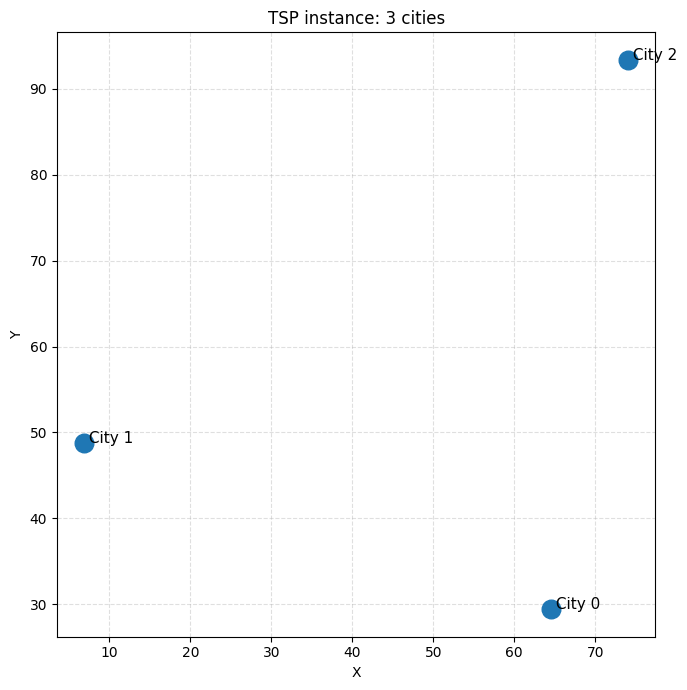

Number of cities: 3
Number of QUBO variables/qubits before transpilation: 9


In [10]:
# Set the number of cities for all example solver blocks in this notebook.
n_cities = 3
# Set a fixed seed so every solver sees the same reproducible TSP instance.
seed = None

# Generate a random symmetric distance matrix and matching city coordinates.
dist, coords = generate_random_distance_matrix(n=n_cities, seed=seed)

# Print the TSP distance matrix used by every solver block.
print("Distance matrix:")
print(dist)

# Plot the generated city coordinates before solving.
plot_tsp_route(coords, title=f"TSP instance: {n_cities} cities")

# Convert the TSP instance into a QUBO matrix shared by all solvers.
Q, n = tsp_to_qubo(dist)

# Print the QUBO size to make the n^2 TSP scaling visible.
print(f"Number of cities: {n}")
print(f"Number of QUBO variables/qubits before transpilation: {Q.shape[0]}")

### 1. Standard QAOA

#### 1.1 Quantum: Qiskit Simulator Using `StatevectorSampler`


Standard QAOA Statevector bitstring:
[1 0 0 0 0 1 0 1 0]
QUBO energy: -14196.000000
      TSP QUBO Solution Decoder

Valid solution found.

    City 0 -> City 2    distance: 64
    City 2 -> City 1    distance: 80
    City 1 -> City 0    distance: 60

  Full route: 0 -> 2 -> 1 -> 0
  Total distance: 204


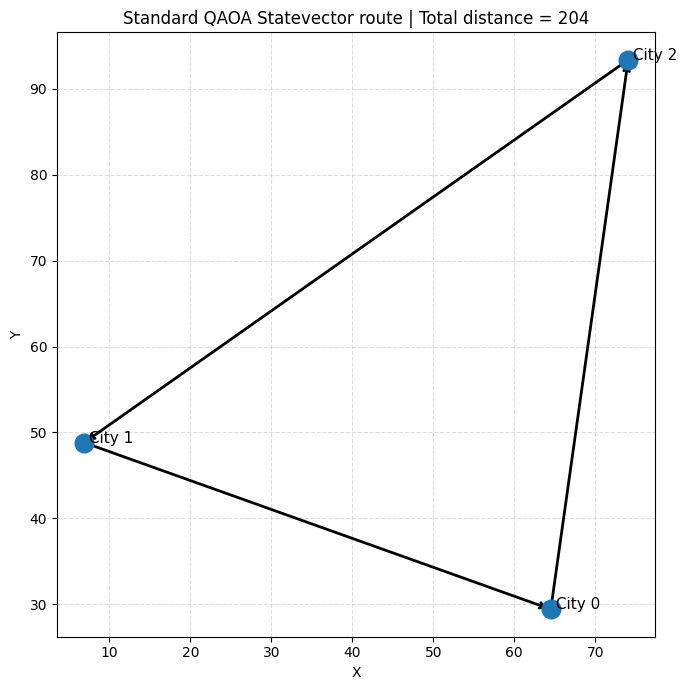

In [11]:
# Solve the shared QUBO with standard QAOA using the ideal local StatevectorSampler.
standard_statevector_result = solve_qubo_with_qaoa(
    Q,
    sampler=StatevectorSampler(seed=seed),
    reps=1,
    maxiter=20,
    seed=seed,
)

# Extract the best bitstring selected by the standard QAOA optimizer wrapper.
standard_statevector_bits = standard_statevector_result["solution"]

# Print the raw bitstring and QUBO energy.
print("Standard QAOA Statevector bitstring:")
print(standard_statevector_bits)
print(f"QUBO energy: {standard_statevector_result['qubo_energy']:.6f}")

# Decode the bitstring into a TSP route if it satisfies all constraints.
decoded = decode_tsp_solution(standard_statevector_bits, dist)

# Plot the decoded route when the solution is valid.
if decoded is not None:
    route, total_dist = decoded
    plot_tsp_route(coords, route=route, title=f"Standard QAOA Statevector route | Total distance = {total_dist:.0f}")

#### 1.2 Quantum: Qiskit Simulator Using Aer `SamplerV2`

In [12]:
# Create a local shot-based Aer sampler.
standard_aer_sampler = make_aer_sampler(shots=4096, seed=seed)
# Create an Aer-specific transpiler so QAOA circuits use supported simulator gates.
standard_aer_transpiler = make_aer_transpiler(seed=seed, optimization_level=1)

# Solve the shared QUBO with standard QAOA using Aer SamplerV2.
standard_aer_result = solve_qubo_with_qaoa(
    Q,
    sampler=standard_aer_sampler,
    reps=1,
    maxiter=20,
    seed=seed,
    transpiler=standard_aer_transpiler,
)

# Extract the best Aer-backed standard QAOA bitstring.
standard_aer_bits = standard_aer_result["solution"]

# Print the raw bitstring and QUBO energy.
print("Standard QAOA Aer bitstring:")
print(standard_aer_bits)
print(f"QUBO energy: {standard_aer_result['qubo_energy']:.6f}")

# Decode the bitstring into a TSP route if it satisfies all constraints.
decoded = decode_tsp_solution(standard_aer_bits, dist)

# Plot the decoded route when the solution is valid.
if decoded is not None:
    route, total_dist = decoded
    plot_tsp_route(coords, route=route, title=f"Standard QAOA Aer route | Total distance = {total_dist:.0f}")

Standard QAOA Aer bitstring:
[1 1 0 0 0 1 0 0 0]
QUBO energy: -9480.000000
      TSP QUBO Solution Decoder
  x City 0 appears 2 times; expected 1.
  x City 2 appears 0 times; expected 1.

Invalid solution; constraints are violated.

Raw bit assignment, city x time:
[[1 1 0]
 [0 0 1]
 [0 0 0]]


#### 1.3 Quantum: IBM Hardware

In [13]:
# Keep hardware execution disabled by default to avoid accidental IBM job submission.
RUN_STANDARD_QAOA_ON_IBM_HARDWARE = False
# Set a backend name such as "ibm_brisbane", or leave None to select the least-busy eligible backend.
IBM_BACKEND_NAME = None

# Only submit the fixed optimized standard-QAOA circuit when explicitly enabled above.
if RUN_STANDARD_QAOA_ON_IBM_HARDWARE:
    # Run the locally optimized standard-QAOA circuit on IBM hardware.
    standard_ibm_result = run_optimized_qaoa_result_on_ibm_hardware(
        standard_statevector_result,
        Q,
        backend_name=IBM_BACKEND_NAME,
        shots=4096,
        optimization_level=3,
    )

    # Extract the best hardware-measured bitstring selected by QUBO energy.
    standard_ibm_bits = standard_ibm_result["best_bits"]

    # Print backend metadata and selected bitstring.
    print("Standard QAOA IBM backend:", standard_ibm_result["backend"].name)
    print("Standard QAOA IBM job ID:", standard_ibm_result["job"].job_id())
    print("Best standard-QAOA IBM measured bitstring:")
    print(standard_ibm_bits)
    print(f"Best measured QUBO energy: {standard_ibm_result['best_energy']:.6f}")
    print(f"Count for selected bitstring: {standard_ibm_result['best_count']}")

    # Decode the selected hardware bitstring into a TSP route if it is valid.
    decoded = decode_tsp_solution(standard_ibm_bits, dist)

    # Plot the decoded hardware route when valid.
    if decoded is not None:
        route, total_dist = decoded
        plot_tsp_route(coords, route=route, title=f"Standard QAOA IBM route | Total distance = {total_dist:.0f}")
else:
    # Explain why this block does nothing during normal run-all execution.
    print("Standard QAOA IBM hardware example skipped. Set RUN_STANDARD_QAOA_ON_IBM_HARDWARE = True to submit a job.")

Standard QAOA IBM hardware example skipped. Set RUN_STANDARD_QAOA_ON_IBM_HARDWARE = True to submit a job.


### 2. Warm-Start QAOA

#### 2.1 Quantum: Qiskit Simulator Using `StatevectorSampler`


Warm-start QAOA Statevector bitstring:
[0 0 1 0 1 0 1 0 0]
QUBO energy: -14196.000000
      TSP QUBO Solution Decoder

Valid solution found.

    City 2 -> City 1    distance: 80
    City 1 -> City 0    distance: 60
    City 0 -> City 2    distance: 64

  Full route: 2 -> 1 -> 0 -> 2
  Total distance: 204


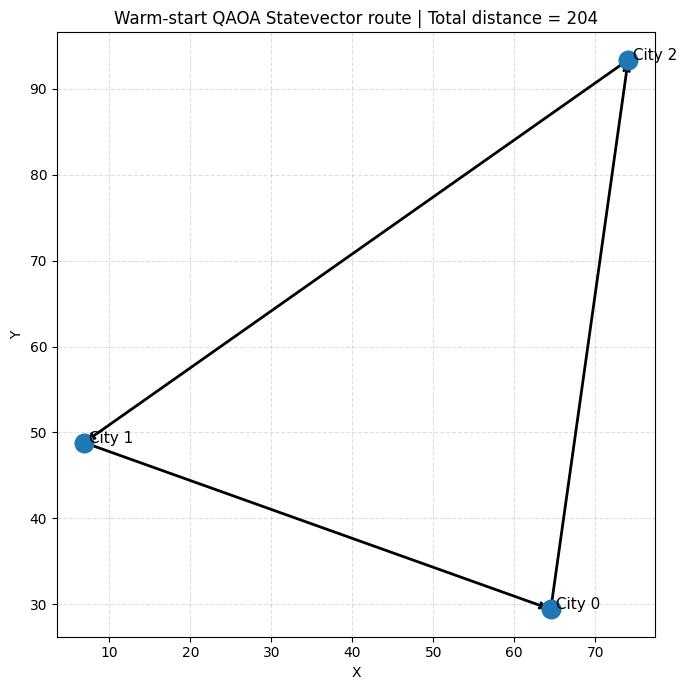

In [14]:
# Solve the shared QUBO with warm-start QAOA using the ideal local StatevectorSampler.
warm_statevector_result = solve_qubo_with_warm_start_qaoa(
    Q,
    sampler=StatevectorSampler(seed=seed),
    reps=1,
    maxiter=20,
    seed=seed,
)

# Extract the warm-start Statevector bitstring.
warm_statevector_bits = warm_statevector_result["solution"]

# Print the raw bitstring and QUBO energy.
print("Warm-start QAOA Statevector bitstring:")
print(warm_statevector_bits)
print(f"QUBO energy: {warm_statevector_result['qubo_energy']:.6f}")

# Decode the bitstring into a TSP route if it satisfies all constraints.
decoded = decode_tsp_solution(warm_statevector_bits, dist)

# Plot the decoded route when the solution is valid.
if decoded is not None:
    route, total_dist = decoded
    plot_tsp_route(coords, route=route, title=f"Warm-start QAOA Statevector route | Total distance = {total_dist:.0f}")

#### 2.2 Quantum: Qiskit Simulator Using Aer `SamplerV2`

Warm-start QAOA Aer bitstring:
[1 0 0 0 1 0 0 0 1]
QUBO energy: -14196.000000
      TSP QUBO Solution Decoder

Valid solution found.

    City 0 -> City 1    distance: 60
    City 1 -> City 2    distance: 80
    City 2 -> City 0    distance: 64

  Full route: 0 -> 1 -> 2 -> 0
  Total distance: 204


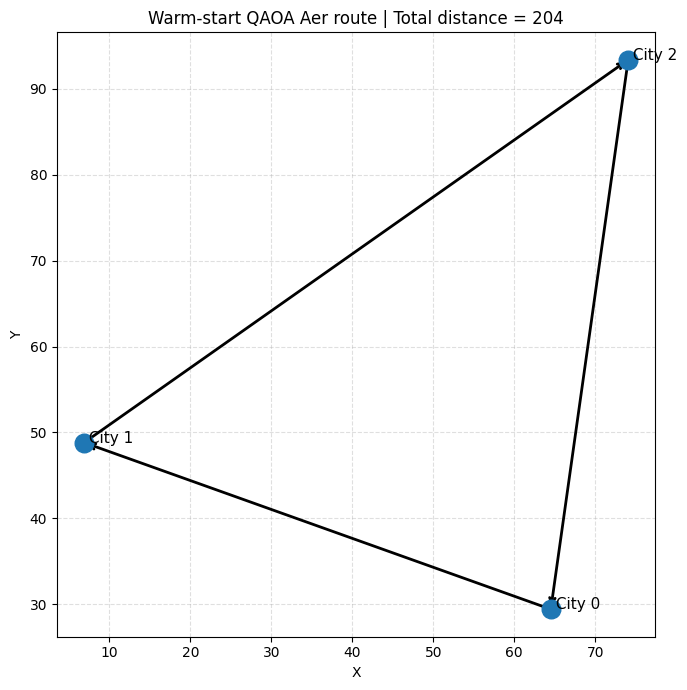

In [15]:
# Create a local shot-based Aer sampler for warm-start QAOA.
warm_aer_sampler = make_aer_sampler(shots=4096, seed=seed)
# Create an Aer-compatible transpiler for the warm-start QAOA circuit.
warm_aer_transpiler = make_aer_transpiler(seed=seed, optimization_level=1)

# Solve the shared QUBO with warm-start QAOA using Aer SamplerV2.
warm_aer_result = solve_qubo_with_warm_start_qaoa(
    Q,
    sampler=warm_aer_sampler,
    reps=1,
    maxiter=20,
    seed=seed,
    transpiler=warm_aer_transpiler,
)

# Extract the warm-start Aer bitstring.
warm_aer_bits = warm_aer_result["solution"]

# Print the raw bitstring and QUBO energy.
print("Warm-start QAOA Aer bitstring:")
print(warm_aer_bits)
print(f"QUBO energy: {warm_aer_result['qubo_energy']:.6f}")

# Decode the bitstring into a TSP route if it satisfies all constraints.
decoded = decode_tsp_solution(warm_aer_bits, dist)

# Plot the decoded route when the solution is valid.
if decoded is not None:
    route, total_dist = decoded
    plot_tsp_route(coords, route=route, title=f"Warm-start QAOA Aer route | Total distance = {total_dist:.0f}")

#### 2.3 Quantum: IBM Hardware

In [16]:
# Keep hardware execution disabled by default to avoid accidental IBM job submission.
RUN_WARM_START_QAOA_ON_IBM_HARDWARE = False
# Reuse the same optional backend name variable used by the standard-QAOA hardware example.
IBM_BACKEND_NAME = None

# Only submit the fixed optimized warm-start QAOA circuit when explicitly enabled above.
if RUN_WARM_START_QAOA_ON_IBM_HARDWARE:
    # Run the locally optimized warm-start QAOA circuit on IBM hardware.
    warm_ibm_result = run_optimized_qaoa_result_on_ibm_hardware(
        warm_statevector_result,
        Q,
        backend_name=IBM_BACKEND_NAME,
        shots=4096,
        optimization_level=3,
    )

    # Extract the best hardware-measured bitstring selected by QUBO energy.
    warm_ibm_bits = warm_ibm_result["best_bits"]

    # Print backend metadata and selected bitstring.
    print("Warm-start QAOA IBM backend:", warm_ibm_result["backend"].name)
    print("Warm-start QAOA IBM job ID:", warm_ibm_result["job"].job_id())
    print("Best warm-start QAOA IBM measured bitstring:")
    print(warm_ibm_bits)
    print(f"Best measured QUBO energy: {warm_ibm_result['best_energy']:.6f}")
    print(f"Count for selected bitstring: {warm_ibm_result['best_count']}")

    # Decode the selected hardware bitstring into a TSP route if it is valid.
    decoded = decode_tsp_solution(warm_ibm_bits, dist)

    # Plot the decoded hardware route when valid.
    if decoded is not None:
        route, total_dist = decoded
        plot_tsp_route(coords, route=route, title=f"Warm-start QAOA IBM route | Total distance = {total_dist:.0f}")
else:
    # Explain why this block does nothing during normal run-all execution.
    print("Warm-start QAOA IBM hardware example skipped. Set RUN_WARM_START_QAOA_ON_IBM_HARDWARE = True to submit a job.")

Warm-start QAOA IBM hardware example skipped. Set RUN_WARM_START_QAOA_ON_IBM_HARDWARE = True to submit a job.


### 3. Classical: Gurobi Solver

In [17]:
# Check whether Gurobi is available without stopping the rest of the notebook.
try:
    # Import Gurobi's Python package.
    import gurobipy as gp
    # Mark Gurobi as available for later cells.
    GUROBI_AVAILABLE = True
    # Print package and solver engine versions for reproducibility.
    print("gurobipy package version:", gp.__version__)
    print("Gurobi engine version:", gp.gurobi.version())

    # Create a tiny model to confirm that the Gurobi license/environment can instantiate models.
    model = gp.Model()
    print("Model created successfully")
except Exception as exc:
    # Mark Gurobi as unavailable so later cells can skip cleanly.
    GUROBI_AVAILABLE = False
    # Print the reason instead of raising, allowing quantum examples and benchmarks to continue.
    print(f"Gurobi is not available in this environment: {type(exc).__name__}: {exc}")

gurobipy package version: 13.0.2
Gurobi engine version: (13, 0, 2)
Restricted license - for non-production use only - expires 2027-11-29
Model created successfully


In [18]:
# Import OS helpers for writing infeasibility diagnostics if Gurobi finds an infeasible model.
import os
# Import NumPy for QUBO matrix manipulation.
import numpy as np

# Only define the Gurobi solver when the package and license check above succeeded.
if globals().get("GUROBI_AVAILABLE", False):
    # Import common Gurobi constants, model type annotations, and expression helper.
    from gurobipy import GRB, Model, quicksum

    def solve_optimization_model_with_gurobi(op_model: Model, label: str):
        """
        Optimize a Gurobi model and return variable values.

        Args:
            op_model: Gurobi model to optimize.
            label: Label used for diagnostic files.

        Returns:
            Dictionary mapping variable names to floating-point values.

        Raises:
            Exception: If Gurobi does not return a usable solution.
        """
        # Allow a 30% optimality gap; this is fast but not an exact classical optimum.
        op_model.setParam("MIPGap", 0.3)
        # Relax integrality feasibility tolerance slightly for numerical robustness.
        op_model.setParam("IntFeasTol", 1e-3)
        # Focus Gurobi on finding feasible integer solutions quickly.
        op_model.setParam("MIPFocus", 1)

        # Run the optimization.
        op_model.optimize()

        # If Gurobi proves optimality within requested tolerances, return variable values.
        if op_model.status == GRB.OPTIMAL:
            return {var.VarName: var.X for var in op_model.getVars()}

        # If the model is infeasible, write an IIS file to help debug conflicting constraints.
        if op_model.status == GRB.INFEASIBLE:
            print("! Model is infeasible.")
            print("  Computing IIS...")
            op_model.computeIIS()

            # Write IIS output to a local writable directory.
            output_dir = os.environ.get(
                "INFEASIBLE_DIR",
                os.path.join("Source", "solutions", "infeasibles"),
            )
            os.makedirs(output_dir, exist_ok=True)

            # Build the IIS file path and ask Gurobi to write it.
            output_file = os.path.join(output_dir, f"{label}_infeasible.ilp")
            op_model.write(output_file)

            # Try a feasibility relaxation so a diagnostic solution can still be inspected.
            op_model.feasRelaxS(1, True, False, True)
            op_model.optimize()

            # Return the relaxed model's best variable values.
            print("+ Returning the best relaxed solution...")
            return {var.VarName: var.X for var in op_model.getVars()}

        # Report common non-success statuses before raising an exception.
        if op_model.status == GRB.UNBOUNDED:
            print("! Model is unbounded.")
        elif op_model.status == GRB.INF_OR_UNBD:
            print("! Model is infeasible or unbounded, reaching infinity.")
        elif op_model.status == GRB.TIME_LIMIT:
            print("! Time limit reached")
        elif op_model.status == GRB.INTERRUPTED:
            print("! Optimization interrupted.")

        # Stop execution when Gurobi did not return a usable solution.
        raise Exception("Optimization was not successful.")

    def solve_qubo_with_gurobi(Q: np.ndarray, label: str = "qubo") -> np.ndarray:
        """
        Solve a QUBO matrix with Gurobi.

        Args:
            Q: Square QUBO matrix defining x^T Q x.
            label: Label used for Gurobi diagnostic output files.

        Returns:
            Integer NumPy bitstring selected by Gurobi.
        """
        # Validate that Q is a square matrix before creating variables.
        Q = validate_qubo_matrix(Q)
        # Number of binary variables in the QUBO.
        n = Q.shape[0]

        # Symmetrize the objective because x_i*x_j and x_j*x_i are the same binary product.
        Q_sym = np.triu(Q + Q.T)
        # Keep diagonal terms counted once because x_i^2 = x_i for binary variables.
        np.fill_diagonal(Q_sym, np.diag(Q))

        # Create a new Gurobi model for this QUBO.
        model = gp.Model(label)
        # Suppress Gurobi's solve log; set to 1 while debugging.
        model.setParam("OutputFlag", 0)

        # Add one binary decision variable for each QUBO bit.
        x = model.addVars(n, vtype=GRB.BINARY, name="x")

        # Build the QUBO objective from diagonal linear terms and upper-triangular quadratic terms.
        obj = quicksum(Q_sym[i, i] * x[i] for i in range(n)) + \
              quicksum(Q_sym[i, j] * x[i] * x[j]
                       for i in range(n)
                       for j in range(i + 1, n)
                       if Q_sym[i, j] != 0)

        # Tell Gurobi to minimize the QUBO objective.
        model.setObjective(obj, GRB.MINIMIZE)

        # Solve the model and get a dictionary like {"x[0]": 0.0, "x[1]": 1.0, ...}.
        solution = solve_optimization_model_with_gurobi(model, label)

        # Convert Gurobi's floating-point binary values into an integer NumPy bitstring.
        return np.array([int(round(solution[f"x[{i}]"])) for i in range(n)])
else:
    # Define a placeholder that raises a clear message if someone runs the Gurobi solve cell anyway.
    def solve_qubo_with_gurobi(Q: np.ndarray, label: str = "qubo") -> np.ndarray:
        """
        Placeholder Gurobi solver used when Gurobi is unavailable.

        Args:
            Q: Square QUBO matrix.
            label: Unused label kept for API compatibility.

        Raises:
            RuntimeError: Always, because Gurobi is unavailable.
        """
        # Raise a clear actionable error.
        raise RuntimeError("Gurobi is not available; install gurobipy and configure a license to run this solver.")


Gurobi QUBO bitstring:
[0 0 1 1 0 0 0 1 0]
QUBO energy: -14196.000000
      TSP QUBO Solution Decoder

Valid solution found.

    City 1 -> City 2    distance: 80
    City 2 -> City 0    distance: 64
    City 0 -> City 1    distance: 60

  Full route: 1 -> 2 -> 0 -> 1
  Total distance: 204


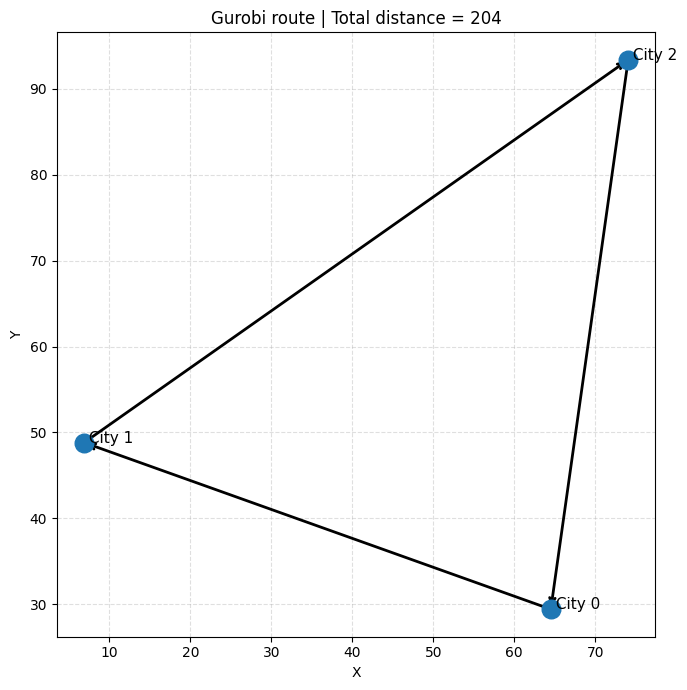

In [19]:
# Run this example block only when the Gurobi package and license are available.
if globals().get("GUROBI_AVAILABLE", False):
    # Solve the same QUBO matrix using the classical Gurobi model.
    gurobi_bits = solve_qubo_with_gurobi(Q)

    # Print the raw Gurobi bitstring and its QUBO energy.
    print("\nGurobi QUBO bitstring:")
    print(gurobi_bits)
    print(f"QUBO energy: {qubo_energy(Q, gurobi_bits):.6f}")

    # Decode the Gurobi bitstring into a TSP route if it satisfies all constraints.
    decoded = decode_tsp_solution(gurobi_bits, dist)

    # Plot the decoded Gurobi route if it is valid.
    if decoded is not None:
        route, total_dist = decoded
        plot_tsp_route(coords, route=route, title=f"Gurobi route | Total distance = {total_dist:.0f}")
else:
    # Keep run-all execution moving when Gurobi is not installed or licensed.
    print("Skipping Gurobi solve because Gurobi is not available in this environment.")

### Benchmarking

In [20]:
# Benchmark problem settings: this section defines its own TSP instance independently of the example sections above.
BENCH_N_CITIES = 3
BENCH_SEED = None

# Generate the benchmark TSP instance independently from the example cells.
BENCH_DIST, BENCH_COORDS = generate_random_distance_matrix(n=BENCH_N_CITIES, seed=BENCH_SEED)

# Convert the benchmark TSP instance into its own QUBO matrix.
BENCH_Q, BENCH_N = tsp_to_qubo(BENCH_DIST)

# Print benchmark problem details so the table and plots are self-describing.
print("Benchmark distance matrix:")
print(BENCH_DIST)
print(f"Benchmark number of cities: {BENCH_N}")
print(f"Benchmark number of QUBO variables/qubits before transpilation: {BENCH_Q.shape[0]}")

# Solver flags: set any solver to False to skip it in the benchmark.
BENCH_STANDARD_STATEVECTOR = True
BENCH_STANDARD_AER = True
BENCH_STANDARD_IBM_HARDWARE = False
BENCH_WARM_STATEVECTOR = True
BENCH_WARM_AER = True
BENCH_WARM_IBM_HARDWARE = False
BENCH_GUROBI = True

# Metric plot flags: set any metric to False to skip that plot.
PLOT_ROUTE_DISTANCE = True
PLOT_QUBO_ENERGY = False
PLOT_RUNTIME = True
PLOT_VALIDITY = False
PLOT_RELATIVE_ERROR = False

# Shared benchmark settings for all QAOA-style solvers.
BENCH_REPS = 1
BENCH_MAXITER = 20
BENCH_SHOTS = 4096
BENCH_IBM_BACKEND_NAME = None

Benchmark distance matrix:
[[  0. 100.  88.]
 [100.   0.  33.]
 [ 88.  33.   0.]]
Benchmark number of cities: 3
Benchmark number of QUBO variables/qubits before transpilation: 9


Solver                             Valid    Optimal/Decoded Route     Distance  Rel. err.    QUBO energy  Runtime (s)
------------------------------------------------------------------------------------------------------------------------
Standard QAOA Statevector           True         1 -> 2 -> 0 -> 1      221.000     0.000%     -17779.000      58.9801
Standard QAOA Aer                   True         2 -> 1 -> 0 -> 2      221.000     0.000%     -17779.000       0.6792
Warm-start QAOA Statevector         True         0 -> 1 -> 2 -> 0      221.000     0.000%     -17779.000      15.2141
Warm-start QAOA Aer                 True         0 -> 1 -> 2 -> 0      221.000     0.000%     -17779.000       0.6867
Classical Gurobi                    True         1 -> 2 -> 0 -> 1      221.000     0.000%     -17779.000       0.0051


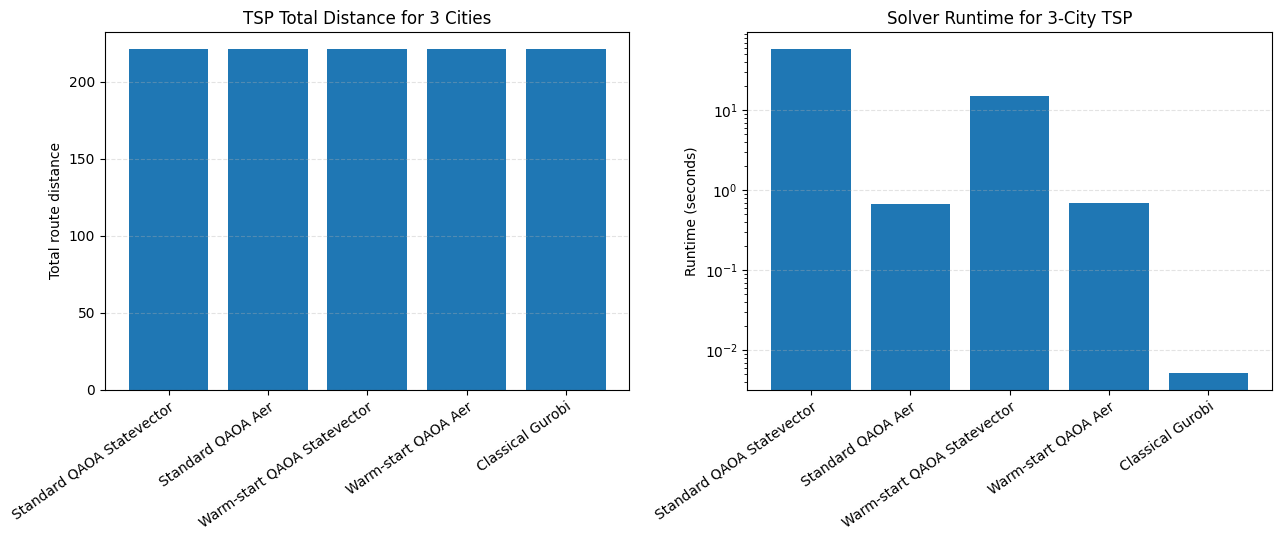

In [21]:
# Store benchmark rows as each enabled solver finishes.
benchmark_rows = []
# Store raw solver result dictionaries for later inspection if needed.
benchmark_raw_results = {}

# Benchmark standard QAOA with StatevectorSampler when enabled.
if BENCH_STANDARD_STATEVECTOR:
    standard_statevector_bench = timed_solver_run(
        "Standard QAOA Statevector",
        solve_qubo_with_qaoa,
        BENCH_Q,
        sampler=StatevectorSampler(seed=BENCH_SEED),
        reps=BENCH_REPS,
        maxiter=BENCH_MAXITER,
        seed=BENCH_SEED,
    )
    benchmark_raw_results["Standard QAOA Statevector"] = standard_statevector_bench
    benchmark_rows.append(summarize_solver_result("Standard QAOA Statevector", standard_statevector_bench, BENCH_Q, BENCH_DIST))

# Benchmark standard QAOA with Aer SamplerV2 when enabled.
if BENCH_STANDARD_AER:
    standard_aer_bench = timed_solver_run(
        "Standard QAOA Aer",
        solve_qubo_with_qaoa,
        BENCH_Q,
        sampler=make_aer_sampler(shots=BENCH_SHOTS, seed=BENCH_SEED),
        reps=BENCH_REPS,
        maxiter=BENCH_MAXITER,
        seed=BENCH_SEED,
        transpiler=make_aer_transpiler(seed=BENCH_SEED, optimization_level=1),
    )
    benchmark_raw_results["Standard QAOA Aer"] = standard_aer_bench
    benchmark_rows.append(summarize_solver_result("Standard QAOA Aer", standard_aer_bench, BENCH_Q, BENCH_DIST))

# Benchmark standard QAOA with IBM hardware sampling when enabled.
if BENCH_STANDARD_IBM_HARDWARE:
    # Locally optimize standard QAOA before timing the hardware sampling path.
    standard_for_ibm = benchmark_raw_results.get("Standard QAOA Statevector") or solve_qubo_with_qaoa(
        BENCH_Q,
        sampler=StatevectorSampler(seed=BENCH_SEED),
        reps=BENCH_REPS,
        maxiter=BENCH_MAXITER,
        seed=BENCH_SEED,
    )
    # Time only the IBM hardware submission/result path for the fixed optimized circuit.
    start = perf_counter()
    standard_ibm_bench = run_optimized_qaoa_result_on_ibm_hardware(
        standard_for_ibm,
        BENCH_Q,
        backend_name=BENCH_IBM_BACKEND_NAME,
        shots=BENCH_SHOTS,
        optimization_level=3,
    )
    standard_ibm_bench["solution"] = standard_ibm_bench["best_bits"]
    standard_ibm_bench["runtime_seconds"] = perf_counter() - start
    benchmark_raw_results["Standard QAOA IBM"] = standard_ibm_bench
    benchmark_rows.append(summarize_solver_result("Standard QAOA IBM", standard_ibm_bench, BENCH_Q, BENCH_DIST))

# Benchmark warm-start QAOA with StatevectorSampler when enabled.
if BENCH_WARM_STATEVECTOR:
    warm_statevector_bench = timed_solver_run(
        "Warm-start QAOA Statevector",
        solve_qubo_with_warm_start_qaoa,
        BENCH_Q,
        sampler=StatevectorSampler(seed=BENCH_SEED),
        reps=BENCH_REPS,
        maxiter=BENCH_MAXITER,
        seed=BENCH_SEED,
    )
    benchmark_raw_results["Warm-start QAOA Statevector"] = warm_statevector_bench
    benchmark_rows.append(summarize_solver_result("Warm-start QAOA Statevector", warm_statevector_bench, BENCH_Q, BENCH_DIST))

# Benchmark warm-start QAOA with Aer SamplerV2 when enabled.
if BENCH_WARM_AER:
    warm_aer_bench = timed_solver_run(
        "Warm-start QAOA Aer",
        solve_qubo_with_warm_start_qaoa,
        BENCH_Q,
        sampler=make_aer_sampler(shots=BENCH_SHOTS, seed=BENCH_SEED),
        reps=BENCH_REPS,
        maxiter=BENCH_MAXITER,
        seed=BENCH_SEED,
        transpiler=make_aer_transpiler(seed=BENCH_SEED, optimization_level=1),
    )
    benchmark_raw_results["Warm-start QAOA Aer"] = warm_aer_bench
    benchmark_rows.append(summarize_solver_result("Warm-start QAOA Aer", warm_aer_bench, BENCH_Q, BENCH_DIST))

# Benchmark warm-start QAOA with IBM hardware sampling when enabled.
if BENCH_WARM_IBM_HARDWARE:
    # Locally optimize warm-start QAOA before timing the hardware sampling path.
    warm_for_ibm = benchmark_raw_results.get("Warm-start QAOA Statevector") or solve_qubo_with_warm_start_qaoa(
        BENCH_Q,
        sampler=StatevectorSampler(seed=BENCH_SEED),
        reps=BENCH_REPS,
        maxiter=BENCH_MAXITER,
        seed=BENCH_SEED,
    )
    # Time only the IBM hardware submission/result path for the fixed optimized circuit.
    start = perf_counter()
    warm_ibm_bench = run_optimized_qaoa_result_on_ibm_hardware(
        warm_for_ibm,
        BENCH_Q,
        backend_name=BENCH_IBM_BACKEND_NAME,
        shots=BENCH_SHOTS,
        optimization_level=3,
    )
    warm_ibm_bench["solution"] = warm_ibm_bench["best_bits"]
    warm_ibm_bench["runtime_seconds"] = perf_counter() - start
    benchmark_raw_results["Warm-start QAOA IBM"] = warm_ibm_bench
    benchmark_rows.append(summarize_solver_result("Warm-start QAOA IBM", warm_ibm_bench, BENCH_Q, BENCH_DIST))

# Benchmark Gurobi when enabled and available.
if BENCH_GUROBI:
    try:
        gurobi_bench = timed_solver_run(
            "Classical Gurobi",
            lambda matrix: {"solution": solve_qubo_with_gurobi(matrix)},
            BENCH_Q,
        )
        benchmark_raw_results["Classical Gurobi"] = gurobi_bench
        benchmark_rows.append(summarize_solver_result("Classical Gurobi", gurobi_bench, BENCH_Q, BENCH_DIST))
    except Exception as exc:
        print(f"Skipping Classical Gurobi benchmark: {type(exc).__name__}: {exc}")

# Use the best valid route distance among completed solvers as the reference for relative error.
valid_distances = [row["route_distance"] for row in benchmark_rows if row["valid"] and not np.isnan(row["route_distance"])]
benchmark_baseline_distance = min(valid_distances) if valid_distances else None

# Recompute rows with the baseline distance so relative error is filled consistently.
benchmark_rows = [
    summarize_solver_result(
        row["solver"],
        {"solution": row["bitstring"], "runtime_seconds": row["runtime_seconds"]},
        BENCH_Q,
        BENCH_DIST,
        baseline_distance=benchmark_baseline_distance,
    )
    for row in benchmark_rows
]

# Print the final benchmark comparison table.
print_benchmark_table(benchmark_rows)

# Plot only the metrics enabled by the plot flags above.
plot_selected_benchmark_metrics(
    benchmark_rows,
    n_cities=BENCH_N_CITIES,
    plot_route_distance=PLOT_ROUTE_DISTANCE,
    plot_qubo_energy=PLOT_QUBO_ENERGY,
    plot_runtime=PLOT_RUNTIME,
    plot_validity=PLOT_VALIDITY,
    plot_relative_error=PLOT_RELATIVE_ERROR,
)

I tried running the benchmarking for `n_cities = 4` and my laptop kept running for 90 mins before I had to interrupt the session with no result.